In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import random
import os
import math
import matplotlib.pyplot as plt
from collections import defaultdict

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


✅ Using device: cuda


## Task 0: Dataset — 1000 Indian Names


In [ ]:
# CELL 2: 1000 Full Names
# LLM-generated list of 1000 Indian full names (first name + surname).

NAMES_RAW = [
    # North Indian Male
    "Aarav Sharma","Aarush Gupta","Aayush Verma","Abhinav Singh","Abhishek Mishra",
    "Aditya Kumar","Ajay Pandey","Akash Tiwari","Akshat Srivastava","Alok Yadav",
    "Amit Chauhan","Amitabh Shukla","Amol Dubey","Anil Tripathi","Anirudh Bajpai",
    "Anish Saxena","Ankit Agarwal","Ankur Chaudhary","Anshul Rastogi","Anuj Kapoor",
    "Arjun Rajput","Arun Malhotra","Ashish Joshi","Ashok Dixit","Ashutosh Dwivedi",
    "Atul Sinha","Ayush Kushwaha","Chirag Bansal","Deepak Lal","Dhruv Bhatnagar",
    "Dinesh Agnihotri","Gaurav Bhatt","Girish Awasthi","Gopal Yadav","Harish Tomar",
    "Harsh Katiyar","Hemant Gautam","Hitesh Nigam","Ishan Mathur","Jagdish Upadhyay",
    "Jatin Pathak","Karan Walia","Kunal Mehrotra","Lalit Tandon","Mahesh Soni",
    "Manoj Khanna","Manish Garg","Mohit Arora","Mohan Chandra","Mukesh Lamba",
    "Neeraj Bhardwaj","Nikhil Rathore","Nilesh Dikshit","Nitin Virmani","Pankaj Nayyar",
    "Parth Oberoi","Piyush Anand","Prakash Varma","Prasad Kesarwani","Prashant Tiwari",
    "Praveen Srivastava","Raghav Misra","Rahul Gandhi","Rajat Sharma","Rajesh Kumar",
    "Rajiv Bhatia","Rakesh Sehgal","Ram Asthana","Ramesh Patel","Ravi Shastri",
    "Ritesh Chourasia","Rohit Bajaj","Rohan Mehra","Sachin Tendulkar","Samir Jain",
    "Sanjay Dutt","Sanket Goswami","Santosh Pandey","Satish Kanojia","Shyam Bihari",
    "Suresh Prabhu","Tarun Tejpal","Tushar Gandhi","Uday Narayan","Umesh Gupta",
    "Vijay Malhotra","Vikas Bajpai","Vinay Dixit","Vinod Khanna","Vivek Oberoi",
    "Yash Chopra","Yogesh Ahuja","Siddharth Singh","Kartik Aaryan","Tejas Bhatt",
    "Atharv Sharma","Krish Kapoor","Aryan Saxena","Dev Anand","Veer Pratap",
    # North Indian Female
    "Aarti Sharma","Aayushi Gupta","Aditi Verma","Akanksha Singh","Amrita Mishra",
    "Ananya Kumar","Anjali Pandey","Anita Tiwari","Archana Srivastava","Asha Yadav",
    "Asmita Chauhan","Bhavna Shukla","Chandni Dubey","Deepa Tripathi","Deepika Bajpai",
    "Devika Saxena","Diksha Agarwal","Divya Chaudhary","Gita Rastogi","Gunjan Kapoor",
    "Harsha Rajput","Jyoti Malhotra","Kajal Joshi","Kavita Dixit","Kavya Dwivedi",
    "Kiran Sinha","Komal Kushwaha","Kritika Bansal","Lata Lal","Madhuri Bhatnagar",
    "Mamta Agnihotri","Manisha Bhatt","Maya Awasthi","Meena Yadav","Meera Tomar",
    "Mehak Katiyar","Monika Gautam","Muskan Nigam","Nandini Mathur","Neha Upadhyay",
    "Nisha Pathak","Pallavi Walia","Payal Mehrotra","Pooja Tandon","Poonam Soni",
    "Preethi Khanna","Priya Garg","Priyanka Arora","Radha Chandra","Ragini Lamba",
    "Rashmi Bhardwaj","Rekha Rathore","Ritu Dikshit","Riya Virmani","Ruchi Nayyar",
    "Ruhi Oberoi","Sakshi Anand","Sangeeta Varma","Sapna Kesarwani","Shalini Tiwari",
    "Shivani Srivastava","Shreya Misra","Shweta Gandhi","Simran Sharma","Sneha Kumar",
    "Sonal Bhatia","Sonia Sehgal","Sunita Patel","Swati Shastri","Tanya Chourasia",
    "Tanvi Bajaj","Uma Mehra","Usha Tendulkar","Varsha Jain","Veena Goswami",
    "Vidya Pandey","Yamini Kanojia","Anushka Bihari","Khushi Prabhu","Disha Tejpal",
    "Alia Bhatt","Kareena Kapoor","Kiara Advani","Shraddha Kapoor","Kriti Sanon",
    "Disha Patani","Tara Sutaria","Ananya Panday","Sara Ali Khan","Janhvi Kapoor",
    "Mrunal Thakur","Bhumi Pednekar","Taapsee Pannu","Vaani Kapoor","Nushrratt Bharuccha",
    "Radhika Madan","Fatima Sana Shaikh","Sanya Malhotra","Yami Gautam","Ileana DCruz",
    # South Indian Male
    "Arjun Krishnaswamy","Ashwin Venkataraman","Balaji Subramaniam","Bhaskar Raghunathan",
    "Chandrasekar Iyer","Dinakaran Pillai","Ganesh Sundaram","Gokul Natarajan",
    "Govindarajan Raman","Hariharan Nair","Jayakumar Menon","Karthik Balasubramanian",
    "Karthikeyan Murugan","Krishnamurthy Annamalai","Lakshman Seshadri","Mani Shankar",
    "Manivannan Rajendran","Murali Krishnan","Muthu Pandian","Nataraj Swaminathan",
    "Naveen Chandrasekhar","Prabhu Deva","Prasanna Venkatesan","Raghunath Aiyar",
    "Rajagopalan Narasimhan","Rajan Thyagarajan","Ramachandran Suresh","Saravanan Kannan",
    "Selvam Arumugam","Selvakumar Perumal","Shankar Mahadevan","Siva Prasad",
    "Sundaram Viswanathan","Venkatesan Ramaswamy","Vijayakumar Gopalan","Vishal Sekar",
    "Suresh Babu","Sudhakar Rao","Thirumalai Naicker","Soundarajan Mudaliar",
    "Aditya Chola","Bhairav Prasad","Chellappa Nadar","Dhanush Raj","Elango Cheran",
    "Gopinath Muthuswamy","Harishankar Namboothiri","Ilangovan Reddy","Jeeva Thomas",
    "Kamal Haasan","Madhavan Ranganathan","Nagarjuna Akkineni","Omprakash Hegde",
    "Pawan Kalyan","Rajnikanth Shivaji","Siddharth Narayan",
    "Tarun Gopi","Uday Kiran","Vijay Setupathi","Vikram Kennedy","Yashwanth Gowda",
    "Allu Arjun","Mahesh Babu","Ram Charan","Prabhas Raju",
    "Ravi Teja","Nani Ghanta","Vijay Deverakonda","Dulquer Salmaan","Fahadh Faasil",
    "Nivin Pauly","Tovino Thomas","Prithviraj Sukumaran","Sudeep Sanjeev","Puneeth Rajkumar",
    "Darshan Thoogudeepa","Yash Gowda","Rakshit Shetty","Rishab Shetty","Upendra Rao",
    "Mammootty Panaparambil","Mohanlal Viswanathan","Kamalakar Rao","Venkatesh Daggubati",
    "Nandamuri Balakrishna","Chiranjeevi Konidela","Prakash Raj","Sathyaraj Subbaiah",
    "Vadivelu Natarajan","Santhanam N","Yogi Babu","Soori Muthuchamy","Goundamani Subramaniyan",
    "Senthil Kumar","Vivek Vivekanandan","Manobala Mahadevan","Charle Thangavel","Delhi Ganesh",
    # South Indian Female
    "Alamelu Krishnan","Ambika Subramaniam","Annapurna Raghunathan","Bhavani Pillai",
    "Geetha Sundaram","Hema Natarajan","Indira Raman","Janaki Nair","Jayalakshmi Menon",
    "Jyothi Balasubramanian","Kamala Murugan","Kavitha Annamalai","Keerthana Seshadri",
    "Lalitha Shankar","Malathi Rajendran","Meenakshi Krishnan","Mythili Pandian",
    "Nirmala Swaminathan","Padma Chandrasekhar","Padmavathi Deva","Prabhavathi Venkatesan",
    "Ranjitha Aiyar","Revathi Narasimhan","Saraswathi Thyagarajan","Savithri Suresh",
    "Shanthi Kannan","Soundarya Arumugam","Sridevi Perumal","Subhashini Mahadevan",
    "Sumathi Prasad","Umamaheswari Viswanathan","Vasantha Gopalan","Vijayalakshmi Sekar",
    "Yamuna Babu","Yasodha Rao","Thamarai Naicker","Sharanya Mudaliar",
    "Dhivya Krishnan","Kiruthika Subramaniam","Nithya Raghunathan","Gowri Pillai",
    "Santhiya Sundaram","Hemamalini Natarajan","Subha Raman","Divya Nair",
    "Anushka Shetty","Samantha Ruth Prabhu","Nayanthara Kurian","Trisha Krishnan",
    "Kajal Aggarwal","Tamannaah Bhatia","Keerthy Suresh",
    "Sai Pallavi","Rashmika Mandanna","Pooja Hegde","Shruti Haasan",
    "Hansika Motwani","Shriya Saran","Genelia DSouza",
    "Asin Thottumkal","Bhoomika Chawla","Meera Jasmine","Navya Nair",
    "Kavya Madhavan","Manju Warrier","Shobana Chandrakumar","Revathi Menon",
    "Suhasini Maniratnam","Radhika Sarathkumar","Ramya Krishnan","Nadhiya Moidu",
    "Kushboo Sundar","Meena Durairaj","Roja Selvamani","Simran Bagga",
    "Jyothika Saravanan","Laila Mehdin","Sneha Prasanna","Sadha Syed",
    "Gopika Anto","Priyamani R","Bhavana Menon","Nithya Menen",
    "Nazriya Nazim","Parvathy Thiruvothu","Aishwarya Lekshmi","Aparna Balamurali",
    "Kalyani Priyadarshan","Anupama Parameswaran","Sai Dhanshika","Varalaxmi Sarathkumar",
    "Aishwarya Rajesh","Regina Cassandra","Nivetha Thomas","Nivetha Pethuraj",
    "Raashii Khanna","Malavika Mohanan","Amala Paul","Oviya Helen",
    # Muslim Names
    "Abdullah Khan","Adnan Sheikh","Ahmad Mirza","Ahmed Siddiqui","Akbar Hussain",
    "Ali Qureshi","Arif Ansari","Asif Malik","Ayaan Baig","Azhar Farooqui",
    "Fahad Usmani","Faisal Rizvi","Farhan Nomani","Faris Alvi","Ghulam Nabi",
    "Hassan Raza","Hussain Bukhari","Ibrahim Chishti","Idris Gilani","Imran Hashmi",
    "Iqbal Durrani","Irfan Pathan","Ismail Sait","Jabir Memon","Junaid Jamshed",
    "Kamran Akmal","Khalid Mehmood","Majid Nawaz","Mansoor Ali","Mohammed Rafi",
    "Mustafa Kamal","Naeem Akhtar","Nasir Hussain","Nawaz Sharif","Omar Farooq",
    "Rashid Latif","Riaz Ahmed","Rizwan Ahmed","Saleem Malik","Salman Khan",
    "Shahid Afridi","Shakeel Badayuni","Tariq Farouk","Umar Akmal","Waseem Akram",
    "Yasir Shah","Yusuf Pathan","Zafar Iqbal","Zaid Hamid","Zubair Ahmed",
    "Aisha Siddiqui","Amina Begum","Asma Khan","Ayesha Mirza","Azra Farooqui",
    "Bilkis Usmani","Bushra Rizvi","Fatima Nomani","Fauzia Alvi","Gulnaz Nabi",
    "Hafsa Raza","Hamida Bukhari","Hasina Chishti","Huma Gilani","Khadija Hashmi",
    "Lubna Durrani","Mariam Pathan","Nasreen Sait","Nazia Memon","Noor Jamshed",
    "Parveen Akmal","Rabia Mehmood","Rehana Nawaz","Rukhsana Ali","Sabrina Kamal",
    "Saira Akhtar","Salma Hussain","Shabana Latif","Shaheen Ahmed","Shaista Rizwana",
    "Shamim Farooq","Sobia Akmal","Sumbul Pasha","Tabassum Begum","Tahira Naz",
    "Yasmeen Khan","Yasmin Sheikh","Zainab Mirza","Zara Hussain","Zohra Qureshi",
    "Shah Rukh Khan","Aamir Khan","Saif Ali Khan","Naseeruddin Shah","Irfan Khan",
    "Nawazuddin Siddiqui","Zakir Hussain","Javed Akhtar",
    # Sikh / Punjabi
    "Amarjit Singh","Amrik Kaur","Angad Pal","Avtar Singh","Balwinder Kaur",
    "Bikram Singh","Dalvir Kaur","Daljit Singh","Gurbachan Singh","Gurdeep Kaur",
    "Gurjit Singh","Gurpreet Kaur","Gurmeet Singh","Hardeep Kaur","Harjit Singh",
    "Harjinder Kaur","Harpreet Singh","Jagdeep Kaur","Jagjit Singh","Jagmeet Kaur",
    "Jaskaran Singh","Jaspal Kaur","Jaswinder Singh","Kulwinder Kaur","Lakhvir Singh",
    "Mandeep Kaur","Manjit Singh","Navdeep Kaur","Navjot Singh","Parminder Kaur",
    "Ravinder Singh","Sarabjit Kaur","Simranjit Singh","Sukhdev Kaur","Sukhwinder Singh",
    "Taranjit Kaur","Tejinder Singh","Paramjit Kaur","Satnam Singh","Gurnam Kaur",
    "Amandeep Singh","Amrita Kaur","Balvinder Singh","Baljinder Kaur","Gurleen Singh",
    "Harjot Kaur","Inderjit Singh","Jasbir Kaur","Kiranjit Singh","Kuljit Kaur",
    "Manjinder Singh","Navneet Kaur","Parmjit Singh","Rajdeep Kaur","Sukhpreet Singh",
    "Kirandeep Kaur","Navpreet Singh","Ravneet Kaur","Rupinder Singh","Satinder Kaur",
    "Diljit Dosanjh","Gippy Grewal","Ammy Virk","Hardy Sandhu","Jassie Gill",
    "Guru Randhawa","Mika Singh","Daler Mehndi","Sukhbir Singh",
    "Karan Aujla","Sidhu Moosewala","Babbu Maan","Gurdas Maan","Harbhajan Mann",
    "Neeru Bajwa","Sonam Bajwa","Sargun Mehta","Himanshi Khurana","Shehnaaz Gill",
    "Mahie Gill","Surveen Chawla","Gul Panag","Mandy Takhar","Wamiqa Gabbi",
    "Tania Singh","Nimrat Khaira","Sunanda Sharma","Jasmine Sandlas",
    "Asees Kaur","Harshdeep Kaur","Kanika Kapoor","Neha Kakkar",
    # Bengali
    "Abhijit Banerjee","Animesh Chatterjee","Aniruddha Mukherjee","Anirban Bose",
    "Arnab Ganguly","Arpan Ghosh","Avik Dasgupta","Avijit Sen","Bhaskar Roy",
    "Bikash Mondal","Biplab Datta","Chiranjit Mitra","Debashis Majumdar","Debasish Pal",
    "Dipankar Biswas","Dipayan Chakraborty","Goutam Bhattacharya","Indrajit Lahiri",
    "Joy Sarkar","Kalyan Guha","Mrinal Seal","Partha Sarathi","Pradip Nandi",
    "Pronoy Kundu","Rajarshi Bhaduri","Rounak Sanyal","Sandip Bhowmik","Sanjib Das",
    "Saurav Ganguly","Somnath Kar","Souvik Halder","Subhajit Mandal","Subir Chaudhuri",
    "Sudip Karmakar","Sujoy Mukherjee","Surojit Basu","Tamal Dey","Tapan Sinha",
    "Tathagata Ghosal","Kaushik Basu","Satyajit Ray",
    "Arpita Banerjee","Barnali Chatterjee","Chandrima Mukherjee","Debasmita Bose",
    "Dipika Ganguly","Enakshi Ghosh","Gopa Dasgupta","Indrani Sen","Ishita Roy",
    "Jhuma Mondal","Kakoli Datta","Kalyani Mitra","Madhumita Majumdar","Mallika Pal",
    "Mithu Biswas","Moumita Chakraborty","Nabanita Bhattacharya","Nilanjana Lahiri",
    "Parna Sarkar","Pritha Guha","Promita Seal","Ratna Nandi","Rimi Kundu",
    "Rina Bhaduri","Rohini Sanyal","Rupali Bhowmik","Sanchita Das","Sharmistha Ganguly",
    "Sohini Kar","Sreelekha Halder","Sudipta Mandal","Swapna Chaudhuri","Tapasi Karmakar",
    "Trisha Mukherjee","Suparna Basu","Susmita Dey","Sharanya Ghosal","Bratati Ray",
    "Prosenjit Chatterjee","Dev Adhikari","Jeet Madnani","Abir Chatterjee","Parambrata Chatterjee",
    "Ritwick Chakraborty","Jisshu Sengupta","Saswata Chatterjee","Ankush Hazra","Yash Dasgupta",
    "Rituparna Sengupta","Koel Mallick","Srabanti Chatterjee","Subhashree Ganguly","Nusrat Jahan",
    # Marathi
    "Amol Patil","Aniket Kulkarni","Chetan Desai","Dhananjay Joshi","Ganesh Bhosale",
    "Kedar Deshpande","Milind Khandekar","Prathamesh Pawar","Sarang Nene","Shekhar Salve",
    "Vaibhav Gaikwad","Vilas Mane","Yashwant Gosavi","Abhijeet Thakur","Avinash Dhuri",
    "Devendra Fadnavis","Pramod Mahajan","Suhas Khamkar","Shirish Gokhale","Swapnil Adate",
    "Aishwarya Patil","Aparna Kulkarni","Ashwini Desai","Deepali Joshi","Gauri Bhosale",
    "Hruta Durgule","Kanchan Deshpande","Madhura Khandekar","Mrunali Pawar","Mugdha Nene",
    "Namrata Salve","Nilima Gaikwad","Prachi Mane","Prajakta Gosavi","Rachna Thakur",
    "Rujuta Dhuri","Sharvari Fadnavis","Shraddha Mahajan","Siddhi Khamkar","Smita Gokhale",
    "Supriya Adate","Vrushali Patil","Manasi Kulkarni","Pooja Desai","Rupali Joshi",
    "Ajinkya Rahane","Rohit Sharma","Shreyas Iyer","Shardul Thakur","Suryakumar Yadav",
    "Rituraj Gaikwad","Kedar Jadhav","Zaheer Khan","Sunil Gavaskar","Sachin Pilgaonkar",
    "Ashok Saraf","Laxmikant Berde","Mahesh Kothare","Nana Patekar","Riteish Deshmukh",
    "Shreyas Talpade","Makrand Deshpande","Atul Kulkarni","Siddharth Jadhav","Swwapnil Joshi",
    "Ankush Chaudhari","Amey Wagh","Lalit Prabhakar","Subodh Bhave","Prasad Oak",
    "Sonali Kulkarni","Sai Tamhankar","Amruta Khanvilkar","Priya Bapat","Mukta Barve",
    "Sonalee Kulkarni","Neha Pendse","Spruha Joshi","Tejaswini Pandit","Urmila Kothare",
    "Mithila Palkar","Shriya Pilgaonkar","Radhika Apte","Smita Patil","Madhuri Dixit",
    "Usha Mangeshkar","Asha Bhosle","Lata Mangeshkar","Kishori Amonkar",
    # Gujarati
    "Alpesh Patel","Bhavesh Shah","Darshan Mehta","Harshad Desai","Hiren Modi",
    "Jignesh Trivedi","Kalpesh Parikh","Kamlesh Thakkar","Keyur Bhatt","Kirtan Jani",
    "Kuntal Pandya","Mihir Vora","Neel Kothari","Parag Kapadia","Pratik Soni",
    "Ronak Choksi","Sagar Rawal","Shailesh Doshi","Utsav Shroff","Vishvesh Naik",
    "Anjana Patel","Bansri Shah","Charmi Mehta","Dharti Desai","Dipti Modi",
    "Falak Trivedi","Heena Parikh","Hirva Thakkar","Jalpa Bhatt","Jinal Jani",
    "Khyati Pandya","Krupa Vora","Manali Kothari","Minal Kapadia","Mitali Soni",
    "Palak Choksi","Riddhi Rawal","Roshni Doshi","Sejal Shroff","Tejal Naik",
    "Trusha Patel","Urvi Shah","Nishi Mehta","Nirali Desai","Vrinda Modi",
    "Hardik Pandya","Krunal Pandya","Jasprit Bumrah","Ravindra Jadeja","Cheteshwar Pujara",
    "Parthiv Patel","Axar Patel","Munaf Patel",
    "Narendra Modi","Amit Shah","Sardar Patel","Mahatma Gandhi","Vikram Sarabhai",
    "Dhirubhai Ambani","Mukesh Ambani","Gautam Adani","Azim Premji","Uday Kotak",
    "Pratik Gandhi","Malhar Thakar","Yash Soni","Mitra Gadhvi","Aarjav Trivedi",
    "Darshan Jariwala","Dilip Joshi","Deven Bhojani","Paresh Rawal","Boman Irani",
    "Disha Vakani","Ketki Dave","Supriya Pathak","Ratna Pathak","Apara Mehta",
    "Sarita Joshi","Bhavya Gandhi","Samay Shah","Kush Shah","Nidhi Bhanushali",
    "Kinjal Dave","Geeta Rabari","Falguni Pathak","Aishwarya Majmudar","Bhoomi Trivedi",
    "Darshan Raval","Osman Mir","Kirtidan Gadhvi","Aditya Gadhvi","Jigardan Gadhavi",
    # Mixed / Pan-Indian
    "Aanchal Srivastava","Aastha Mehta","Abhilasha Singh","Abha Sharma","Ahana Gupta",
    "Amisha Verma","Amulya Reddy","Anagha Nair","Anvita Pillai","Anya Iyer",
    "Apurva Krishnan","Arhan Menon","Arjita Bose","Arpit Chakraborty","Arsha Nair",
    "Atharva Patil","Avani Kulkarni","Avantika Desai","Avika Joshi","Avishi Patel",
    "Ayana Shah","Ayra Mehta","Bani Singh","Bavya Krishnamurthy","Bhagat Singh",
    "Bhakti Sharma","Bharati Ghosh","Bhavana Iyer","Bhavini Pillai","Bhavya Nair",
    "Chetna Banerjee","Chitra Mukherjee","Daksha Rao","Darshi Reddy","Devanshi Menon",
    "Dhara Bose","Dhaval Chakraborty","Dikshit Nair","Drashti Patil","Drishti Kulkarni",
    "Easha Desai","Ekta Joshi","Elina Patel","Eshanvi Shah","Eshika Mehta",
    "Falguni Singh","Gargi Sharma","Garima Ghosh","Gaurangi Iyer","Geetanjali Pillai",
    "Girija Nair","Gitanjali Banerjee","Gopi Mukherjee","Govinda Rao","Grishma Reddy",
    "Hansa Menon","Hardi Bose","Hardik Chakraborty","Harini Nair","Hetal Patil",
    "Himani Kulkarni","Himanshu Desai","Himanshi Joshi","Hiral Patel","Hrishi Shah",
    "Hrishikesh Mehta","Ila Singh","Ishaan Sharma","Ishaani Ghosh","Ishika Iyer",
    "Jagriti Pillai","Janhavi Nair","Janvi Banerjee","Jayesh Mukherjee","Jheel Rao",
    "Kadambari Reddy","Kalindi Menon","Kalki Bose","Kalpana Chakraborty","Kamakshi Nair",
    "Kanishk Patil","Kartik Kulkarni","Kashvi Desai","Kaveri Joshi","Keshav Patel",
    "Kiara Shah","Kinjal Mehta","Kirti Singh","Kratika Sharma","Krisha Ghosh",
    "Kundan Iyer","Kushal Pillai","Lakshita Nair","Lavanya Banerjee","Leena Mukherjee",
    "Madhav Rao","Madhavi Reddy","Mahima Menon","Mahir Bose","Maithili Chakraborty",
    "Maitri Nair","Mangala Patil","Manju Kulkarni","Mannat Desai","Manthan Joshi",
    "Medha Patel","Meghna Shah","Mihika Mehta","Miloni Singh","Misha Sharma",
    "Mohana Ghosh","Mohini Iyer","Mudit Pillai","Mukta Nair","Mukul Banerjee",
    "Aahan Trivedi","Advait Bhasin","Bhuvaneshwari Iyer","Chiranjeev Thakur","Daksh Singhal",
    "Eklavya Pandit","Gagandeep Sandhu","Hemantika Das","Ira Sengupta",
    "Jashn Soni","Kiaan Wadhwa","Lekha Mathur","Mokshith Reddy","Niharika Chawla",
    "Ojaswi Patel","Prisha Katiyar","Riyansh Goyal","Samaira Ahuja",
    "Tanishq Lamba","Utkarsh Bajpai","Vivaan Somani","Waris Khan","Xitij Verma",
    "Yugantar Pandey","Zoya Farrukh","Aarohi Kadam","Bodhisattva Sen","Chaitali Mukhopadhyay"
]

# De-duplicate (case-insensitive)
seen = set()
unique_names = []
for n in NAMES_RAW:
    key = n.lower().strip()
    if key not in seen and len(n.split()) == 2:
        seen.add(key)
        unique_names.append(n.strip())

print(f"Total unique full names: {len(unique_names)}")

# Saving TrainingNames.txt
with open("TrainingNames.txt", "w") as f:
    f.write("\n".join(unique_names))
print("Saved TrainingNames.txt")
print("\nSample names (first 10):")
print("\n".join(unique_names[:10]))


Total unique full names: 1001
Saved TrainingNames.txt

Sample names (first 10):
Aarav Sharma
Aarush Gupta
Aayush Verma
Abhinav Singh
Abhishek Mishra
Aditya Kumar
Ajay Pandey
Akash Tiwari
Akshat Srivastava
Alok Yadav


## Preprocessing

In [ ]:
# Vocabulary & Encoding
SOS = '<'
EOS = '>'
SEP = ' '   # space character separates first name and surname

# Building vocab from all characters (lowercase letters + space)
all_chars = sorted(set(c.lower() for name in unique_names for c in name))
vocab = [SOS, EOS] + all_chars   # space will be in all_chars automatically

char_to_idx = {c: i for i, c in enumerate(vocab)}
idx_to_char = {i: c for c, i in char_to_idx.items()}

VOCAB_SIZE = len(vocab)
SOS_IDX   = char_to_idx[SOS]
EOS_IDX   = char_to_idx[EOS]

print(f"Vocabulary size : {VOCAB_SIZE}")
print(f"Chars           : {vocab}")


def name_to_tensor(full_name: str) -> torch.Tensor:
    """'Pari Suresh' → tensor([SOS, p, a, r, i, SPACE, s, u, r, e, s, h, EOS])"""
    s = full_name.lower().strip()
    indices = [SOS_IDX] + [char_to_idx[c] for c in s] + [EOS_IDX]
    return torch.tensor(indices, dtype=torch.long)


def tensor_to_name(tensor) -> str:
    """Convert index tensor back to full name string."""
    chars = []
    for idx in tensor:
        c = idx_to_char.get(int(idx), '')
        if c == EOS:
            break
        if c != SOS:
            chars.append(c)
    return "".join(chars)


def encode_dataset(names):
    return [name_to_tensor(n) for n in names]


# Train / Val split  90 / 10
random.shuffle(unique_names)
split      = int(0.9 * len(unique_names))
train_names = unique_names[:split]
val_names   = unique_names[split:]
train_data  = encode_dataset(train_names)
val_data    = encode_dataset(val_names)

print(f"\nTrain: {len(train_data)} | Val: {len(val_data)}")
example = train_names[0]
print(f"Example full name : '{example}'")
print(f"Tensor            : {name_to_tensor(example).tolist()}")


Vocabulary size : 29
Chars           : ['<', '>', ' ', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

Train: 900 | Val: 101
Example full name : 'Mandy Takhar'
Tensor            : [0, 15, 3, 16, 6, 27, 2, 22, 3, 13, 10, 3, 20, 1]


## Task 1 — Three Models


In [ ]:
# Model 1 — Vanilla RNN
class VanillaRNN(nn.Module):
    """
    Embedding → nn.RNN → Dropout → Linear(H → V)
    """
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.embedding   = nn.Embedding(vocab_size, embed_size)
        self.rnn         = nn.RNN(embed_size, hidden_size, num_layers,
                                  batch_first=True,
                                  dropout=dropout if num_layers > 1 else 0)
        self.dropout     = nn.Dropout(dropout)
        self.fc          = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        emb    = self.dropout(self.embedding(x))
        out, h = self.rnn(emb, hidden)
        return self.fc(self.dropout(out)), h

    def init_hidden(self, batch_size):
        return torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def model_size_mb(self):
        """Returns total size of all trainable parameters in megabytes."""
        total_bytes = sum(p.numel() * p.element_size() for p in self.parameters() if p.requires_grad)
        return total_bytes / (1024 ** 2)

In [ ]:
# Model 2 — Bidirectional LSTM
class BidirectionalLSTM(nn.Module):
    """
    During training: full BiLSTM output → Linear(2H, V).
    During inference: forward-only LSTM cell used.

    A separate fwd_lstm (forward-only LSTM) is trained in parallel
    and used at inference time, since a bidirectional pass requires
    the full sequence (unavailable during autoregressive generation).
    """
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.embedding   = nn.Embedding(vocab_size, embed_size)
        self.bilstm      = nn.LSTM(embed_size, hidden_size, num_layers,
                                   batch_first=True,
                                   dropout=dropout if num_layers > 1 else 0,
                                   bidirectional=True)
        # Forward-only LSTM trained in parallel for autoregressive inference
        self.fwd_lstm    = nn.LSTM(embed_size, hidden_size, num_layers,
                                   batch_first=True,
                                   dropout=dropout if num_layers > 1 else 0,
                                   bidirectional=False)
        self.dropout     = nn.Dropout(dropout)
        self.fc          = nn.Linear(hidden_size * 2, vocab_size)   # BiLSTM head
        self.fc_fwd      = nn.Linear(hidden_size, vocab_size)       # Forward-only head

    def forward(self, x, hidden=None):
        """
        Training pass — uses full BiLSTM.
        Returns logits only (no hidden state); hidden state not needed
        because train_blstm manages optimisation directly.
        """
        emb    = self.dropout(self.embedding(x))
        out, _ = self.bilstm(emb)                 # (B, T, 2H)
        return self.fc(self.dropout(out))          # (B, T, V)

    def step(self, x, hidden):
        """Single-step autoregressive inference using the forward-only LSTM."""
        emb = self.embedding(x)                    # (1, 1, E)
        out, hidden = self.fwd_lstm(emb, hidden)   # (1, 1, H)
        logits = self.fc_fwd(out[:, -1, :])        # (1, V)
        return logits, hidden

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


In [ ]:
# CELL 6: Model 3 — RNN + Bahdanau Attention ────────────
class BahdanauAttention(nn.Module):
    """
    Additive (Bahdanau) attention over encoder hidden states.
    """
    def __init__(self, hidden_size):
        super().__init__()
        self.W1 = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W2 = nn.Linear(hidden_size, hidden_size, bias=False)
        self.v  = nn.Linear(hidden_size, 1,           bias=False)

    def forward(self, h_t, enc_out):
        query   = self.W1(h_t).unsqueeze(1)          # (B, 1, H)
        keys    = self.W2(enc_out)                    # (B, T, H)
        scores  = self.v(torch.tanh(query + keys))    # (B, T, 1)
        weights = F.softmax(scores, dim=1)            # (B, T, 1)
        context = (weights * enc_out).sum(1)          # (B, H)
        return context, weights.squeeze(-1)


class RNNWithAttention(nn.Module):
    """
    Embedding → RNN → Bahdanau Attention over past hidden states
             → Linear([h_t ; context] → V)
    """
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.embedding   = nn.Embedding(vocab_size, embed_size)
        self.rnn         = nn.RNN(embed_size, hidden_size, num_layers,
                                  batch_first=True,
                                  dropout=dropout if num_layers > 1 else 0)
        self.attention   = BahdanauAttention(hidden_size)
        self.dropout     = nn.Dropout(dropout)
        self.fc          = nn.Linear(hidden_size * 2, vocab_size)

    def forward(self, x, hidden=None):
        B, T     = x.shape
        emb      = self.dropout(self.embedding(x))
        enc_out, hidden = self.rnn(emb, hidden)
        logits_list = []
        for t in range(T):
            h_t     = enc_out[:, t, :]
            context = (torch.zeros_like(h_t) if t == 0
                       else self.attention(h_t, enc_out[:, :t, :])[0])
            logits_list.append(self.fc(self.dropout(torch.cat([h_t, context], -1))))
        return torch.stack(logits_list, 1), hidden

    def init_hidden(self, batch_size):
        return torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


In [ ]:
# Hyperparameters & Model Creation
EMBED_SIZE    = 64
HIDDEN_SIZE   = 256
NUM_LAYERS    = 2
DROPOUT       = 0.3
LEARNING_RATE = 0.001
BATCH_SIZE    = 64
EPOCHS        = 80

rnn_model  = VanillaRNN(VOCAB_SIZE, EMBED_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
lstm_model = BidirectionalLSTM(VOCAB_SIZE, EMBED_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
attn_model = RNNWithAttention(VOCAB_SIZE, EMBED_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)

print("=" * 70)
print(f"{'Model':<30} {'Parameters':>12}  {'Size (MB)':>10}")
print("=" * 70)
for name, model in [("Vanilla RNN", rnn_model),
                    ("Bidirectional LSTM", lstm_model),
                    ("RNN with Attention", attn_model)]:
    n_params = model.count_parameters()
    size_mb  = model.model_size_mb() if hasattr(model, 'model_size_mb') else (
        sum(p.numel() * p.element_size() for p in model.parameters() if p.requires_grad) / (1024 ** 2)
    )
    print(f"{name:<30} {n_params:>12,}  {size_mb:>10.4f}")
print("=" * 70)
print(f"\nHyperparameters: embed={EMBED_SIZE}, hidden={HIDDEN_SIZE}, "
      f"layers={NUM_LAYERS}, dropout={DROPOUT}, lr={LEARNING_RATE}, "
      f"batch={BATCH_SIZE}, epochs={EPOCHS}")

Model                            Parameters   Size (MB)
Vanilla RNN                         223,325      0.8519
Bidirectional LSTM                3,116,666     11.8891
RNN with Attention                  362,077      1.3812


## Training


In [ ]:
# Training Utilities
def make_batches(data, batch_size):
    """Yields (input, target) padded tensor pairs."""
    random.shuffle(data)
    for i in range(0, len(data), batch_size):
        batch = sorted(data[i:i+batch_size], key=len, reverse=True)
        max_len = max(len(s) for s in batch)
        inp = torch.zeros(len(batch), max_len - 1, dtype=torch.long)
        tgt = torch.zeros(len(batch), max_len - 1, dtype=torch.long)
        for j, seq in enumerate(batch):
            inp[j, :len(seq)-1] = seq[:-1]
            tgt[j, :len(seq)-1] = seq[1:]
        yield inp.to(device), tgt.to(device)


def compute_val_loss(model, data):
    model.eval()
    crit = nn.CrossEntropyLoss(ignore_index=0)
    total, n = 0.0, 0
    with torch.no_grad():
        for inp, tgt in make_batches(data, BATCH_SIZE):
            logits, _ = model(inp)
            B, T, V = logits.shape
            total += crit(logits.reshape(B*T, V), tgt.reshape(B*T)).item()
            n += 1
    return total / max(n, 1)


def train_model(model, train_data, val_data, epochs, lr, model_name):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
    criterion = nn.CrossEntropyLoss(ignore_index=0)
    train_losses, val_losses = [], []
    best_val, best_state = float('inf'), None

    print(f"\n{'='*50}\nTraining {model_name}\n{'='*50}")
    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss, n = 0.0, 0
        for inp, tgt in make_batches(train_data, BATCH_SIZE):
            optimizer.zero_grad()
            logits, _ = model(inp)
            B, T, V = logits.shape
            loss = criterion(logits.reshape(B*T, V), tgt.reshape(B*T))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            epoch_loss += loss.item(); n += 1

        t_loss = epoch_loss / n
        v_loss = compute_val_loss(model, val_data)
        train_losses.append(t_loss); val_losses.append(v_loss)
        if v_loss < best_val:
            best_val = v_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        scheduler.step()
        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch {epoch:>3}/{epochs} | Train: {t_loss:.4f} | Val: {v_loss:.4f}")

    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    print(f"  ✅ Best val loss: {best_val:.4f}")
    return train_losses, val_losses


def train_blstm(model, train_data, val_data, epochs, lr, model_name):
    """
    Custom trainer for BidirectionalLSTM.

    Two losses are optimised simultaneously each step:
      • loss_bi  — cross-entropy on the full BiLSTM output  (training signal)
      • loss_fwd — cross-entropy on the forward-only head   (trains inference head)

    Only loss_fwd is tracked in the epoch log so the reported curve reflects
    what the model actually uses at generation time.
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
    criterion = nn.CrossEntropyLoss(ignore_index=0)
    train_losses, val_losses = [], []
    best_val, best_state = float('inf'), None

    print(f"\n{'='*50}\nTraining {model_name} (BiLSTM)\n{'='*50}")
    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss, n = 0.0, 0
        for inp, tgt in make_batches(train_data, BATCH_SIZE):
            optimizer.zero_grad()
            B, T = inp.shape

            # BiLSTM loss (training signal for bidirectional encoder)
            logits_bi = model(inp)                     # (B, T, V)
            loss_bi = criterion(logits_bi.reshape(B * T, VOCAB_SIZE),
                                tgt.reshape(B * T))

            # Forward-only LSTM loss (trains the inference head)
            emb = model.dropout(model.embedding(inp))
            out_fwd, _ = model.fwd_lstm(emb)
            logits_fwd = model.fc_fwd(model.dropout(out_fwd))
            loss_fwd = criterion(logits_fwd.reshape(B * T, VOCAB_SIZE),
                                 tgt.reshape(B * T))

            loss = loss_bi + loss_fwd
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

            epoch_loss += loss_fwd.item()
            n += 1

        t_loss = epoch_loss / n

        # Validation uses the forward-only head via compute_val_loss_fwd
        v_loss = compute_val_loss_fwd(model, val_data)
        train_losses.append(t_loss)
        val_losses.append(v_loss)
        if v_loss < best_val:
            best_val = v_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        scheduler.step()
        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch {epoch:>3}/{epochs} | Train: {t_loss:.4f} | Val: {v_loss:.4f}")

    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    print(f"  Best val loss: {best_val:.4f}")
    return train_losses, val_losses


def compute_val_loss_fwd(model, data):
    """Validation loss using the forward-only LSTM head of BidirectionalLSTM."""
    model.eval()
    crit = nn.CrossEntropyLoss(ignore_index=0)
    total, n = 0.0, 0
    with torch.no_grad():
        for inp, tgt in make_batches(data, BATCH_SIZE):
            emb = model.dropout(model.embedding(inp))
            out_fwd, _ = model.fwd_lstm(emb)
            logits = model.fc_fwd(model.dropout(out_fwd))
            B, T, V = logits.shape
            total += crit(logits.reshape(B * T, V), tgt.reshape(B * T)).item()
            n += 1
    return total / max(n, 1)


In [ ]:
# CELL 9: Train All Models ──────────────────────────────
rnn_tr,  rnn_val  = train_model(rnn_model,  train_data, val_data, EPOCHS, LEARNING_RATE, "Vanilla RNN")
lstm_tr, lstm_val = train_blstm(lstm_model, train_data, val_data, EPOCHS, LEARNING_RATE, "Bidirectional LSTM")
attn_tr, attn_val = train_model(attn_model, train_data, val_data, EPOCHS, LEARNING_RATE, "RNN with Attention")



Training Vanilla RNN
  Epoch   1/80 | Train: 2.8959 | Val: 2.5183
  Epoch  10/80 | Train: 2.1509 | Val: 2.0883
  Epoch  20/80 | Train: 1.9976 | Val: 1.9668
  Epoch  30/80 | Train: 1.8916 | Val: 1.9358
  Epoch  40/80 | Train: 1.8406 | Val: 1.9197
  Epoch  50/80 | Train: 1.7734 | Val: 1.8797
  Epoch  60/80 | Train: 1.7843 | Val: 1.8774
  Epoch  70/80 | Train: 1.7161 | Val: 1.8687
  Epoch  80/80 | Train: 1.7221 | Val: 1.8755
  ✅ Best val loss: 1.8506

Training Bidirectional LSTM (BiLSTM)
  Epoch   1/80 | Train: 3.1373 | Val: 2.8959
  Epoch  10/80 | Train: 2.1870 | Val: 2.1268
  Epoch  20/80 | Train: 1.9471 | Val: 1.9500
  Epoch  30/80 | Train: 1.8095 | Val: 1.8717
  Epoch  40/80 | Train: 1.6872 | Val: 1.8272
  Epoch  50/80 | Train: 1.6645 | Val: 1.8448
  Epoch  60/80 | Train: 1.5747 | Val: 1.8203
  Epoch  70/80 | Train: 1.5810 | Val: 1.7972
  Epoch  80/80 | Train: 1.5391 | Val: 1.8071
  Best val loss: 1.7823

Training RNN with Attention
  Epoch   1/80 | Train: 2.8967 | Val: 2.5592
  Epoc

In [ ]:
# Reporting parameter count and model size from the trained Vanilla RNN
rnn_num_params = rnn_model.count_parameters()
rnn_size_mb    = rnn_model.model_size_mb()
print(f"\n  Vanilla RNN — Trained Model Stats:")
print(f"    Parameters : {rnn_num_params:,}")
print(f"    Size (MB)  : {rnn_size_mb:.4f} MB")


  Vanilla RNN — Trained Model Stats:
    Parameters : 223,325
    Size (MB)  : 0.8519 MB


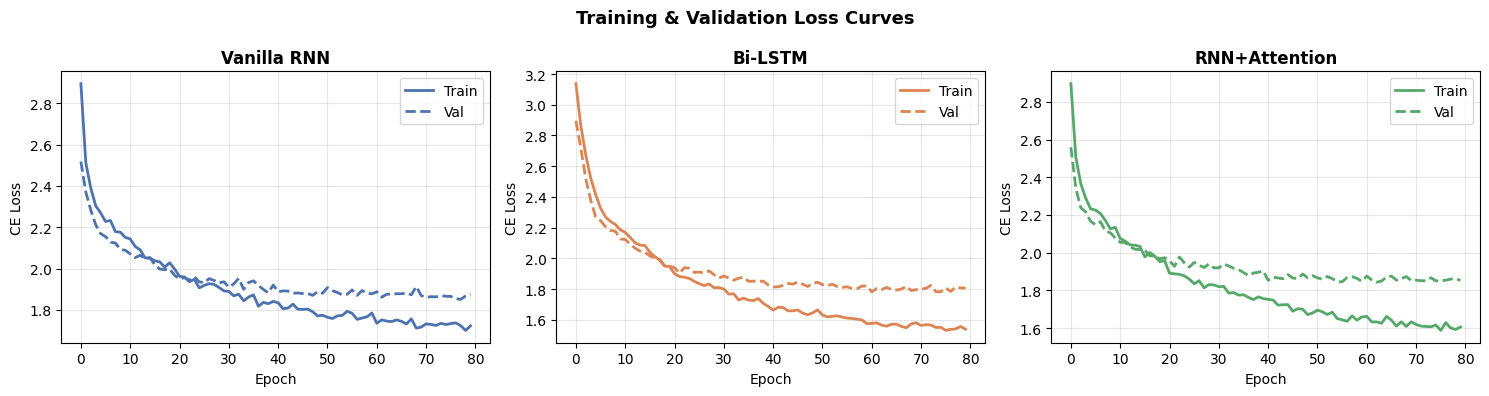

In [ ]:
# Plotting Loss Curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
info = [("Vanilla RNN", rnn_tr, rnn_val, "#4C72B0"),
        ("Bi-LSTM",     lstm_tr, lstm_val, "#DD8452"),
        ("RNN+Attention", attn_tr, attn_val, "#55A868")]
for ax, (name, tr, va, col) in zip(axes, info):
    ax.plot(tr, color=col, lw=2, label="Train")
    ax.plot(va, color=col, lw=2, linestyle="--", label="Val")
    ax.set_title(name, fontweight="bold"); ax.set_xlabel("Epoch")
    ax.set_ylabel("CE Loss"); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle("Training & Validation Loss Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## Generation


In [ ]:
# Generation Functions
def generate_full_name(model, temperature=0.8, max_len=30):
    """
    Autoregressively generates one name.

    For BidirectionalLSTM, uses model.step() which routes through the
    dedicated forward-only LSTM inference head.
    For VanillaRNN and RNNWithAttention, uses the standard model(x, hidden)
    interface.
    """
    model.eval()
    use_step = isinstance(model, BidirectionalLSTM)
    with torch.no_grad():
        x      = torch.tensor([[SOS_IDX]], dtype=torch.long).to(device)
        hidden = None
        chars  = []
        for _ in range(max_len):
            if use_step:
                logits, hidden = model.step(x, hidden)   # (1, V)
                last_logit = logits[0]
            else:
                logits, hidden = model(x, hidden)
                last_logit = logits[0, -1, :]
            last_logit = last_logit / temperature
            probs      = F.softmax(last_logit, dim=-1)
            next_idx   = torch.multinomial(probs, 1).item()
            if next_idx == EOS_IDX:
                break
            if next_idx == SOS_IDX:
                continue
            chars.append(idx_to_char[next_idx])
            x = torch.tensor([[next_idx]], dtype=torch.long).to(device)

        raw = "".join(chars).strip()
        # Ensuring exactly two parts: first name + surname
        parts = [p for p in raw.split(" ") if p]
        if len(parts) < 2:
            return ""          # discard malformed
        # Title-casing each part
        return " ".join(p.capitalize() for p in parts[:2])


def generate_names_batch(model, n=200, temperature=0.8):
    names = []
    attempts = 0
    while len(names) < n and attempts < n * 5:
        name = generate_full_name(model, temperature=temperature)
        if name and len(name) >= 5:   # "A B" minimum
            names.append(name)
        attempts += 1
    return names


In [ ]:
# Generating Samples
N_GENERATE  = 500
TEMPERATURE = 0.8

rnn_gen  = generate_names_batch(rnn_model,  N_GENERATE, TEMPERATURE)
lstm_gen = generate_names_batch(lstm_model, N_GENERATE, TEMPERATURE)
attn_gen = generate_names_batch(attn_model, N_GENERATE, TEMPERATURE)

for fname, samples in [("rnn_generated.txt",  rnn_gen),
                        ("lstm_generated.txt", lstm_gen),
                        ("attn_generated.txt", attn_gen)]:
    with open(fname, "w") as f:
        f.write("\n".join(samples))

## Task 2: Quantitative Evaluation


In [ ]:
# Metric Functions
def novelty_rate(generated, training):
    """% of generated full names not in training set (case-insensitive)."""
    train_set = {n.lower() for n in training}
    novel     = sum(1 for g in generated if g.lower() not in train_set)
    return novel / len(generated) * 100 if generated else 0.0

def diversity_score(generated):
    """Unique generated names / total generated names."""
    return len(set(g.lower() for g in generated)) / len(generated) if generated else 0.0

def avg_name_length(names):
    return float(np.mean([len(n) for n in names])) if names else 0.0

def char_bigram_entropy(names):
    bc = defaultdict(int)
    for n in names:
        s = n.lower()
        for i in range(len(s) - 1):
            bc[s[i:i+2]] += 1
    total = sum(bc.values())
    if not total:
        return 0.0
    return -sum((c/total)*math.log2(c/total) for c in bc.values() if c > 0)

def first_surname_consistency(generated):
    """
    Fraction of generated full names where the first name and surname
    appear to come from the same regional tradition.
    Simple heuristic: check if known regional suffixes/prefixes co-occur.
    """
    south_first = {"arjun","ashwin","balaji","karthik","murali","naveen","prabhu",
                   "saravanan","shankar","siva","suresh","venkat","rajesh","ramesh",
                   "alamelu","ambika","bhavani","geetha","hema","kavitha","lalitha",
                   "meenakshi","nirmala","padma","revathi","saraswathi","shanthi"}
    south_sur   = {"krishnaswamy","venkataraman","subramaniam","raghunathan","iyer",
                   "pillai","sundaram","natarajan","raman","nair","menon","balasubramanian",
                   "murugan","annamalai","seshadri","shankar","krishnan","pandian","kannan",
                   "arumugam","perumal","mahadevan","viswanathan","gopalan","sekar","rao"}
    sikh_first  = {"amarjit","amrik","angad","avtar","balwinder","bikram","daljit",
                   "gurdeep","gurjit","gurpreet","gurmeet","hardeep","harjit","harpreet",
                   "jagdeep","jagjit","jaskaran","jaspal","jaswinder","kulwinder","lakhvir",
                   "mandeep","manjit","navdeep","navjot","parminder","ravinder","sarabjit",
                   "simranjit","sukhdev","sukhwinder","taranjit","tejinder"}
    sikh_sur    = {"singh","kaur","pal"}
    beng_sur    = {"banerjee","chatterjee","mukherjee","bose","ganguly","ghosh","dasgupta",
                   "sen","roy","mondal","datta","mitra","majumdar","pal","biswas","chakraborty",
                   "bhattacharya","lahiri","sarkar","guha","seal","nandi","kundu","bhaduri",
                   "sanyal","bhowmik","das","karmakar","sujoy","basu","dey","ghosal","ray"}

    consistent = 0
    for name in generated:
        parts = name.lower().split()
        if len(parts) < 2:
            continue
        fn, sn = parts[0], parts[1]
        if (fn in south_first and sn in south_sur) or \
           (fn in sikh_first  and sn in sikh_sur)  or \
           (sn in beng_sur):
            consistent += 1
    return consistent / len(generated) * 100 if generated else 0.0


def evaluate(generated, training, model_name):
    r = {
        "model":       model_name,
        "novelty":     novelty_rate(generated, training),
        "diversity":   diversity_score(generated),
        "avg_length":  avg_name_length(generated),
        "bigram_ent":  char_bigram_entropy(generated),
        "consistency": first_surname_consistency(generated),
    }
    print(f"\n{'─'*50}")
    print(f"  Model             : {model_name}")
    print(f"  Novelty Rate      : {r['novelty']:.1f}%")
    print(f"  Diversity         : {r['diversity']:.3f}")
    print(f"  Avg Name Length   : {r['avg_length']:.2f} chars")
    print(f"  Bigram Entropy    : {r['bigram_ent']:.3f} bits")
    print(f"  Regional Consist. : {r['consistency']:.1f}%")
    print(f"{'─'*50}")
    return r


print("\n" + "="*50 + "\n     QUANTITATIVE EVALUATION\n" + "="*50)
results = [evaluate(rnn_gen,  unique_names, "Vanilla RNN"),
           evaluate(lstm_gen, unique_names, "Bidirectional LSTM"),
           evaluate(attn_gen, unique_names, "RNN + Attention")]



     QUANTITATIVE EVALUATION

──────────────────────────────────────────────────
  Model             : Vanilla RNN
  Novelty Rate      : 99.8%
  Diversity         : 0.998
  Avg Name Length   : 12.46 chars
  Bigram Entropy    : 6.996 bits
  Regional Consist. : 1.6%
──────────────────────────────────────────────────

──────────────────────────────────────────────────
  Model             : Bidirectional LSTM
  Novelty Rate      : 99.6%
  Diversity         : 1.000
  Avg Name Length   : 12.57 chars
  Bigram Entropy    : 7.101 bits
  Regional Consist. : 2.8%
──────────────────────────────────────────────────

──────────────────────────────────────────────────
  Model             : RNN + Attention
  Novelty Rate      : 100.0%
  Diversity         : 1.000
  Avg Name Length   : 14.10 chars
  Bigram Entropy    : 7.939 bits
  Regional Consist. : 0.4%
──────────────────────────────────────────────────


/tmp/ipykernel_4036/2558770226.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(mnames, rotation=12, ha="right", fontsize=8)
/tmp/ipykernel_4036/2558770226.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(mnames, rotation=12, ha="right", fontsize=8)
/tmp/ipykernel_4036/2558770226.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(mnames, rotation=12, ha="right", fontsize=8)
/tmp/ipykernel_4036/2558770226.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(mnames, rotation=12, ha="right", fontsize=8)
/tmp/ipykernel_4036/2558770226.py:13: UserWarning: set_ticklabels() shou

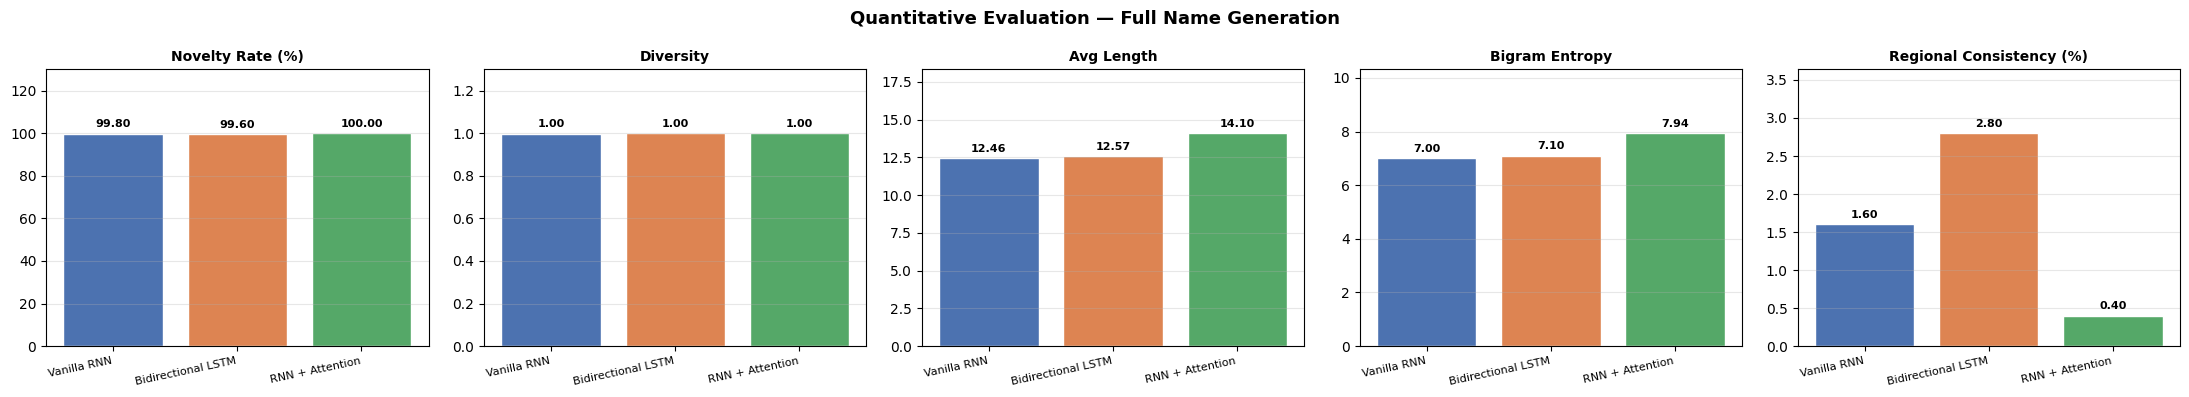

In [ ]:
# Evaluation Bar Charts
metrics = ["novelty","diversity","avg_length","bigram_ent","consistency"]
labels  = ["Novelty Rate (%)","Diversity","Avg Length","Bigram Entropy","Regional Consistency (%)"]
colors  = ["#4C72B0","#DD8452","#55A868"]
mnames  = [r["model"] for r in results]

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, m, lbl in zip(axes, metrics, labels):
    vals = [r[m] for r in results]
    bars = ax.bar(mnames, vals, color=colors, edgecolor="white")
    ax.set_title(lbl, fontsize=10, fontweight="bold")
    ax.set_ylim(0, max(vals)*1.3)
    ax.set_xticklabels(mnames, rotation=12, ha="right", fontsize=8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.02,
                f"{v:.2f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Quantitative Evaluation — Full Name Generation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## Task 3: Qualitative Analysis


In [ ]:
# Sample Generated Names
def show_samples(generated, model_name, n=20):
    print(f"\n{'='*50}")
    print(f"  {model_name} — {n} Sample Generated Names")
    print(f"{'='*50}")
    for i, name in enumerate(random.sample(generated, min(n, len(generated))), 1):
        print(f"  {i:>3}. {name}")

show_samples(rnn_gen,  "Vanilla RNN")
show_samples(lstm_gen, "Bidirectional LSTM")
show_samples(attn_gen, "RNN + Attention")



  Vanilla RNN — 20 Sample Generated Names
    1. Radhuvi Rajushari
    2. Ritesh Ghosh
    3. Rajinder Kaur
    4. Ravpa Kalnanan
    5. Karsi Pallai
    6. Amanth Palhai
    7. Anesh Chauddar
    8. Surhav Naramani
    9. Subha Patel
   10. Supandal Kaur
   11. Sulshi Neram
   12. Iathi Arjan
   13. Inari Singh
   14. Rayash Swadmee
   15. Rish Kaur
   16. Mandit Doshami
   17. Mahanla Patel
   18. Pravya Upikar
   19. Suchinder Sandaj
   20. Sonani Shatta

  Bidirectional LSTM — 20 Sample Generated Names
    1. Diera Sandee
    2. Bhavama Sarbopala
    3. Harish Bosat
    4. Jish Kumar
    5. Sharuna Kanoo
    6. Jajit Singh
    7. Alini Pale
    8. Avim Daspit
    9. Alik Thamem
   10. Suprita Virma
   11. Arudha Mehta
   12. Bopal Shah
   13. Layala Jehot
   14. Mitha Mehta
   15. Nikaja Mehta
   16. Mandur Bixata
   17. Surathi Ruzday
   18. Akshika Mukhar
   19. Hardar Shah
   20. Chandel Singh

  RNN + Attention — 20 Sample Generated Names
    1. Hrjiya Bhpothmer
    2. Somova 

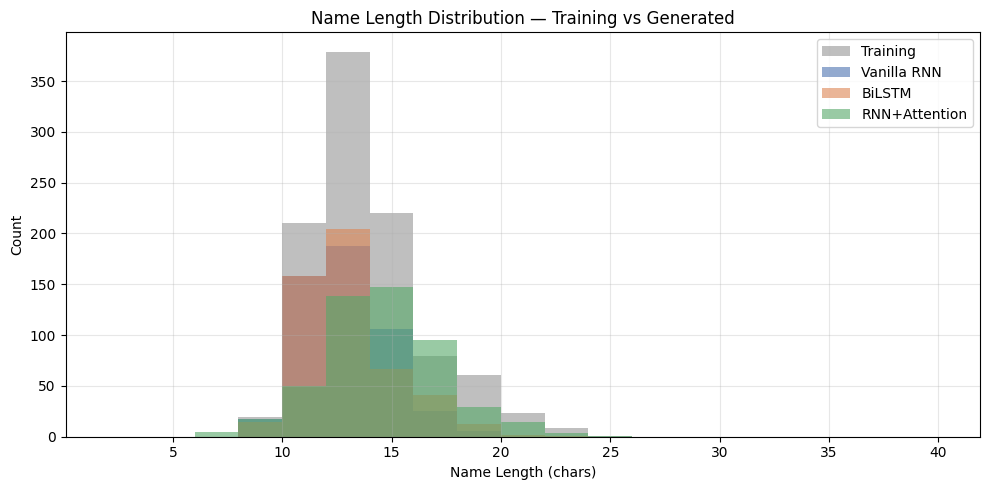

In [ ]:
# Name Length Distribution
fig, ax = plt.subplots(figsize=(10, 5))
bins = range(2, 42, 2)
ax.hist([len(n) for n in unique_names], bins=bins, alpha=0.5, label='Training',      color='gray')
ax.hist([len(n) for n in rnn_gen],      bins=bins, alpha=0.6, label='Vanilla RNN',   color='#4C72B0')
ax.hist([len(n) for n in lstm_gen],     bins=bins, alpha=0.6, label='BiLSTM',        color='#DD8452')
ax.hist([len(n) for n in attn_gen],     bins=bins, alpha=0.6, label='RNN+Attention', color='#55A868')
ax.set_xlabel('Name Length (chars)'); ax.set_ylabel('Count')
ax.set_title('Name Length Distribution — Training vs Generated')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()